In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd

In [3]:
from datetime import datetime, timedelta

In [41]:
import matplotlib.pyplot as plt

In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from skforecast.plot import plot_residuals
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 8})

In [28]:
#df = pd.read_csv("../data/raw/tempload.csv", index_col = "date", parse_dates = True)
#need to drop duplicates
#idk why the extract script is buggy
#chain it all togther
# df isn't defined yet in the df["date"] call so we need to use pipe
df = (pd.read_csv("../data/raw/tempload.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [29]:
# check that the index is complete
start_date = df.index.min()
end_date = df.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=df.index.freq)
is_index_complete = (df.index == complete_date_range).all()
print(f"Index complete: {is_index_complete}")
print(f"Number of rows with missing values: {df.isnull().any(axis=1).mean()}")

Index complete: True
Number of rows with missing values: 0.0009504257907542579


In [30]:
#check for rows with missing values
df[df.isnull().any(axis = 1)]

,Demand,Temperature,is_day
date,,,
2024-02-20 07:00:00,NaN,3.061500,0
2024-02-20 08:00:00,NaN,2.061500,0
2024-02-20 09:00:00,NaN,1.811500,0
2024-02-20 10:00:00,NaN,1.161500,0
2024-02-20 11:00:00,NaN,1.061500,0
2024-02-20 12:00:00,NaN,0.611500,0
2024-02-20 13:00:00,NaN,-0.288500,0
2024-02-20 14:00:00,NaN,1.011500,1
2024-02-20 15:00:00,NaN,5.011500,1


In [31]:
print(f"start of data: {df.index.min()}")
print(f"end of data: {df.index.max()}")

start of data: 2023-01-01 00:00:00
end of data: 2025-12-31 23:00:00


### Train Val Test Split
- Train: 2023-01-01 to 2024-06-30 (18 months)
- Validation: 2024-07-01 to 2024-12-31 (6 months)
- Test: 2025-01-01 to 2025-12-31 (12 months)

In [32]:
TRAIN_START = "2023-01-01 00:00:00"
#datetime(2023, 1, 1, 0, 0, 0)
TRAIN_END   = "2024-06-30 23:00:00"
#datetime(2024, 6, 30, 23, 0, 0)

VAL_START   = "2024-07-01 00:00:00"
#datetime(2024, 7, 1, 0, 0, 0)
VAL_END     = "2024-12-31 23:00:00"
#datetime(2024, 12, 31, 23, 0, 0)

TEST_START  = "2025-01-01 00:00:00"
#datetime(2025, 1, 1, 0, 0, 0)
TEST_END    = "2025-12-31 23:00:00"
#datetime(2025, 12, 31, 23, 0, 0)

In [33]:
data = df.copy()
df = df.sort_index()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Graphs

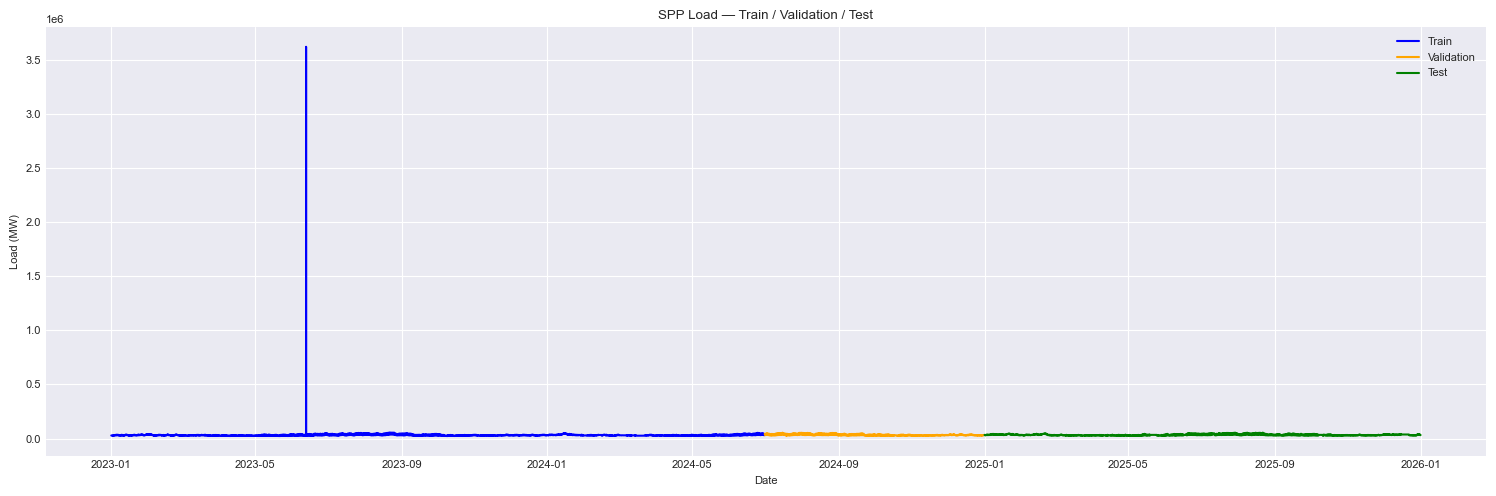

In [44]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_train.index, data_train["Demand"], label="Train", color="blue")
ax.plot(data_val.index, data_val["Demand"], label="Validation", color="orange")
ax.plot(data_test.index, data_test["Demand"], label="Test", color="green")

ax.set_title("SPP Load — Train / Validation / Test")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()